# 01 — EDA for the PhiUSIIL Phishing URL Dataset

This notebook explores the phishing URL dataset before modelling. The aim is to understand the label distribution, missing values, duplicate rows, numeric feature ranges, and the strongest engineered indicators. These checks are important because this dataset contains URL and webpage features that can be highly discriminative.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "PhiUSIIL_Phishing_URL_Dataset.csv"
OUTPUT_DIR = BASE_DIR / "outputs" / "eda_phiusiil"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Working folder:", BASE_DIR)
print("Dataset found:", DATA_PATH.exists())

if not DATA_PATH.exists():
    raise FileNotFoundError("Place PhiUSIIL_Phishing_URL_Dataset.csv in the same folder as this notebook.")

Working folder: C:\Users\rahin\Documents\Masters Course\ML for DS\coursework\bhairebhai\phiusiil_5_member_ipynb_readme_only\member2_eda_feature_separability
Dataset found: True


## Load the dataset

The original `label` column is kept for inspection. Based on the URL examples, label `0` is treated as the phishing class and label `1` as the legitimate class in the modelling notebooks.

In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)

print("Dataset shape:", df.shape)
print("Number of columns:", len(df.columns))
print("Columns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (235795, 56)
Number of columns: 56
Columns:
['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


## Basic data quality checks

These checks are saved as files so they can be used directly when writing the report.

In [3]:
with open(OUTPUT_DIR / "dataset_overview.txt", "w", encoding="utf-8") as f:
    f.write(f"Dataset shape: {df.shape}")
    f.write(f"Duplicate rows: {df.duplicated().sum()}")
    f.write("Label distribution:")
    f.write(str(df["label"].value_counts(dropna=False)))

missing = df.isna().sum().sort_values(ascending=False)
missing.to_csv(OUTPUT_DIR / "missing_values.csv", header=["missing_count"])

print("Duplicate rows:", df.duplicated().sum())
print("Top missing-value columns:")
display(missing.head(20))
print("Label distribution:")
display(df["label"].value_counts(dropna=False))

Duplicate rows: 0
Top missing-value columns:


FILENAME                0
URL                     0
URLLength               0
Domain                  0
DomainLength            0
IsDomainIP              0
TLD                     0
URLSimilarityIndex      0
CharContinuationRate    0
TLDLegitimateProb       0
URLCharProb             0
TLDLength               0
NoOfSubDomain           0
HasObfuscation          0
NoOfObfuscatedChar      0
ObfuscationRatio        0
NoOfLettersInURL        0
LetterRatioInURL        0
NoOfDegitsInURL         0
DegitRatioInURL         0
dtype: int64

Label distribution:


label
1    134850
0    100945
Name: count, dtype: int64

## Label distribution

This plot checks whether the original dataset is heavily imbalanced.

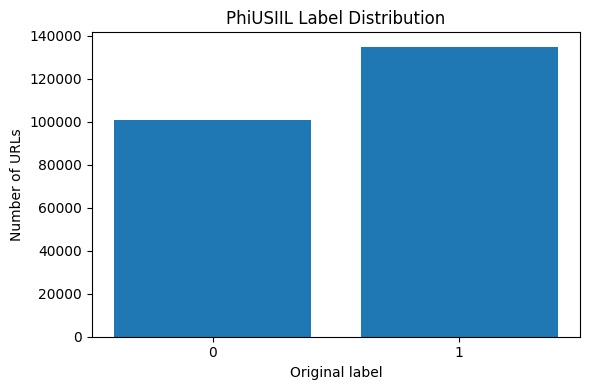

In [4]:
counts = df["label"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar([str(i) for i in counts.index], counts.values)
plt.title("PhiUSIIL Label Distribution")
plt.xlabel("Original label")
plt.ylabel("Number of URLs")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "label_distribution.png", dpi=300)
plt.show()

## Inspect example URLs

This is a simple sanity check for the interpretation of the labels.

In [5]:
if "URL" in df.columns:
    display(df.groupby("label")[["URL"]].head(10))

,URL
0,https://www.southbankmosaics.com
1,https://www.uni-mainz.de
2,https://www.voicefmradio.co.uk
3,https://www.sfnmjournal.com
4,https://www.rewildingargentina.org
5,https://www.globalreporting.org
6,https://www.saffronart.com
7,https://www.nerdscandy.com
8,https://www.hyderabadonline.in
9,https://www.aap.org


## Numeric feature summary

The models use numeric URL and webpage features. Raw text columns such as URL, domain and title are excluded from these tabular models.

In [6]:
text_or_id_cols = ["FILENAME", "URL", "Domain", "Title", "TLD"]
feature_cols = [
    c for c in df.columns
    if c not in text_or_id_cols + ["label"] and pd.api.types.is_numeric_dtype(df[c])
]

summary = df[feature_cols].describe().T
summary["missing"] = df[feature_cols].isna().sum()
summary.to_csv(OUTPUT_DIR / "numeric_feature_summary.csv")

print("Numeric feature count:", len(feature_cols))
display(summary.head(20))

Numeric feature count: 50


,count,mean,std,min,25%,50%,75%,max,missing
URLLength,235795.0,34.573095,41.314153,13.000000,23.000000,27.000000,34.000000,6097.000000,0
DomainLength,235795.0,21.470396,9.150793,4.000000,16.000000,20.000000,24.000000,110.000000,0
IsDomainIP,235795.0,0.002706,0.051946,0.000000,0.000000,0.000000,0.000000,1.000000,0
URLSimilarityIndex,235795.0,78.430778,28.976055,0.155574,57.024793,100.000000,100.000000,100.000000,0
CharContinuationRate,235795.0,0.845508,0.216632,0.000000,0.680000,1.000000,1.000000,1.000000,0
TLDLegitimateProb,235795.0,0.260423,0.251628,0.000000,0.005977,0.079963,0.522907,0.522907,0
URLCharProb,235795.0,0.055747,0.010587,0.001083,0.050747,0.057970,0.062875,0.090824,0
TLDLength,235795.0,2.764456,0.599739,2.000000,2.000000,3.000000,3.000000,13.000000,0
NoOfSubDomain,235795.0,1.164758,0.600969,0.000000,1.000000,1.000000,1.000000,10.000000,0
HasObfuscation,235795.0,0.002057,0.045306,0.000000,0.000000,0.000000,0.000000,1.000000,0


## Feature diagnostics by class

The following engineered features are especially useful for explaining model performance. The plots help show whether the dataset is naturally easy to separate.

IsHTTPS


IsHTTPS,0,1
is_phishing,,
0,0.000000,1.000000
1,0.507762,0.492238


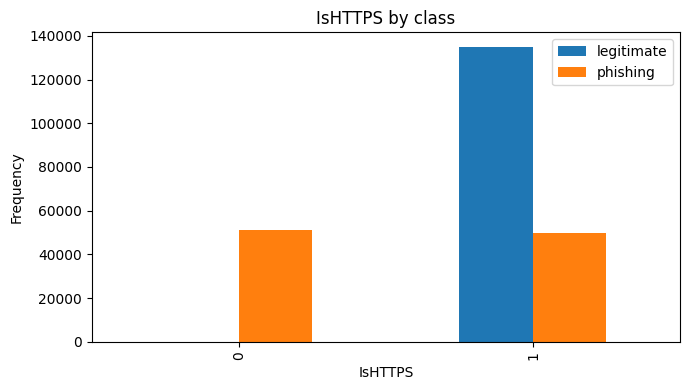

URLSimilarityIndex


,count,mean,std,min,25%,50%,75%,max
is_phishing,,,,,,,,
0,134850.0,100.000000,0.000000,100.000000,100.000000,100.000000,100.000000,100.0
1,100945.0,49.616973,22.572082,0.155574,32.120613,51.419332,67.251462,100.0


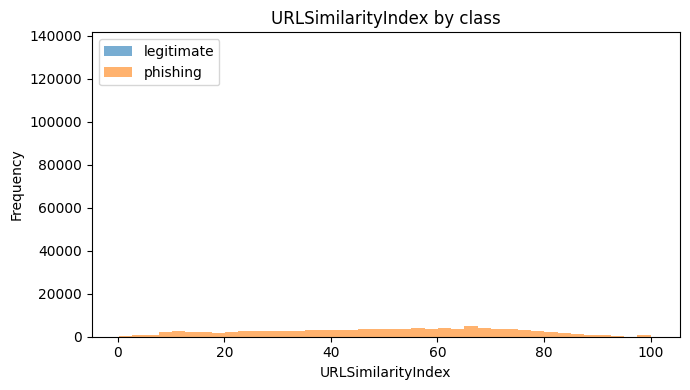

HasDescription


HasDescription,0,1
is_phishing,,
0,0.263367,0.736633
1,0.955837,0.044163


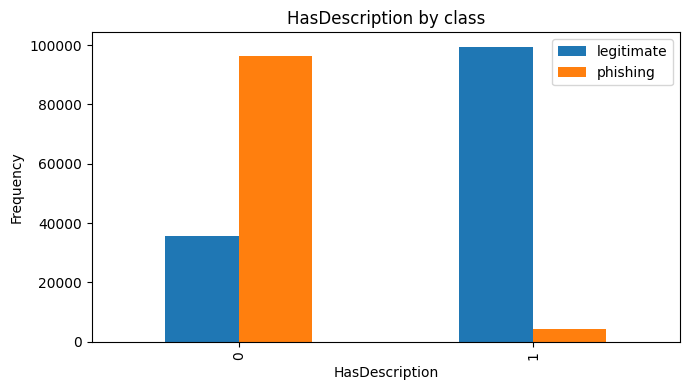

HasCopyrightInfo


HasCopyrightInfo,0,1
is_phishing,,
0,0.191761,0.808239
1,0.942662,0.057338


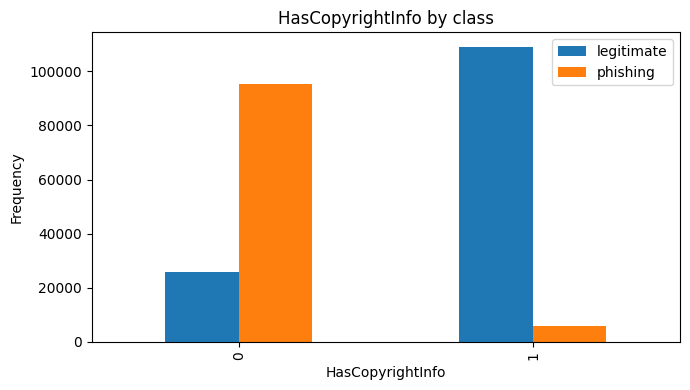

NoOfImage


,count,mean,std,min,25%,50%,75%,max
is_phishing,,,,,,,,
0,134850.0,44.946600,100.930539,0.0,13.0,25.0,47.0,8956.0
1,100945.0,0.866492,3.296497,0.0,0.0,0.0,0.0,158.0


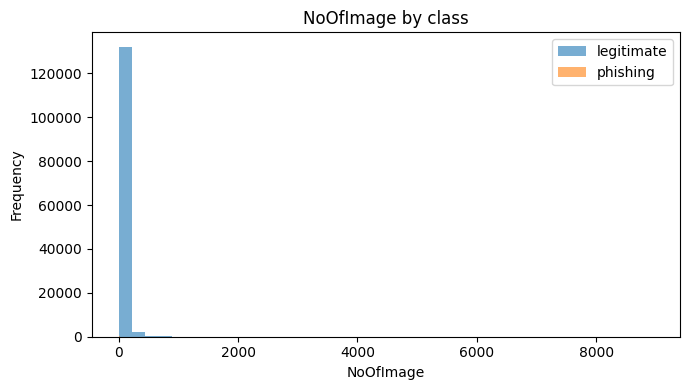

NoOfOtherSpecialCharsInURL


,count,mean,std,min,25%,50%,75%,max
is_phishing,,,,,,,,
0,134850.0,1.244835,0.503961,0.0,1.0,1.0,1.0,7.0
1,100945.0,3.803467,4.998448,1.0,2.0,3.0,5.0,499.0


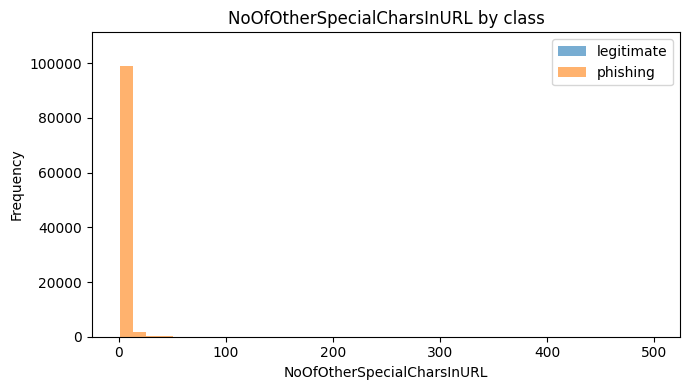

NoOfJS


,count,mean,std,min,25%,50%,75%,max
is_phishing,,,,,,,,
0,134850.0,17.732532,27.213939,0.0,8.0,14.0,23.0,6957.0
1,100945.0,0.890336,3.362975,0.0,0.0,0.0,0.0,102.0


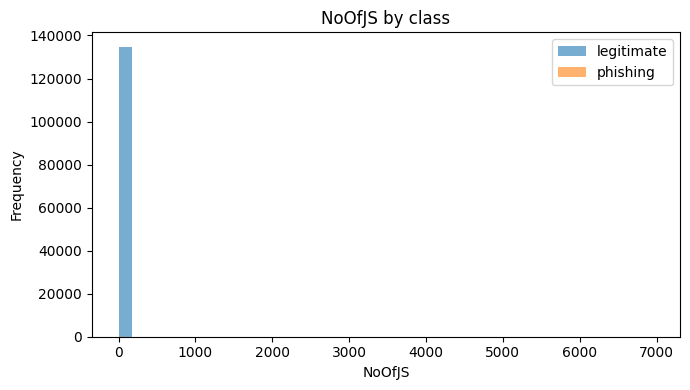

In [7]:
PHISHING_LABEL = 0
df_diag = df.dropna(subset=["label"]).copy()
df_diag["is_phishing"] = (df_diag["label"].astype(int) == PHISHING_LABEL).astype(int)

important_features = ["IsHTTPS", "URLSimilarityIndex", "HasDescription", "HasCopyrightInfo", "NoOfImage", "NoOfOtherSpecialCharsInURL", "NoOfJS"]

for col in important_features:
    if col not in df_diag.columns:
        continue
    print("" + "=" * 80)
    print(col)
    print("=" * 80)
    if df_diag[col].nunique() <= 10:
        display(pd.crosstab(df_diag["is_phishing"], df_diag[col], normalize="index"))
    else:
        display(df_diag.groupby("is_phishing")[col].describe())

    plt.figure(figsize=(7, 4))
    if df_diag[col].nunique() <= 10:
        pd.crosstab(df_diag[col], df_diag["is_phishing"]).plot(kind="bar", ax=plt.gca())
        plt.legend(["legitimate", "phishing"])
    else:
        plt.hist(df_diag.loc[df_diag["is_phishing"] == 0, col], bins=40, alpha=0.6, label="legitimate")
        plt.hist(df_diag.loc[df_diag["is_phishing"] == 1, col], bins=40, alpha=0.6, label="phishing")
        plt.legend()
    plt.title(f"{col} by class")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"eda_{col}.png", dpi=300)
    plt.show()

## Correlation view

A heatmap of the highest-variance numeric features gives a compact view of relationships between predictors.

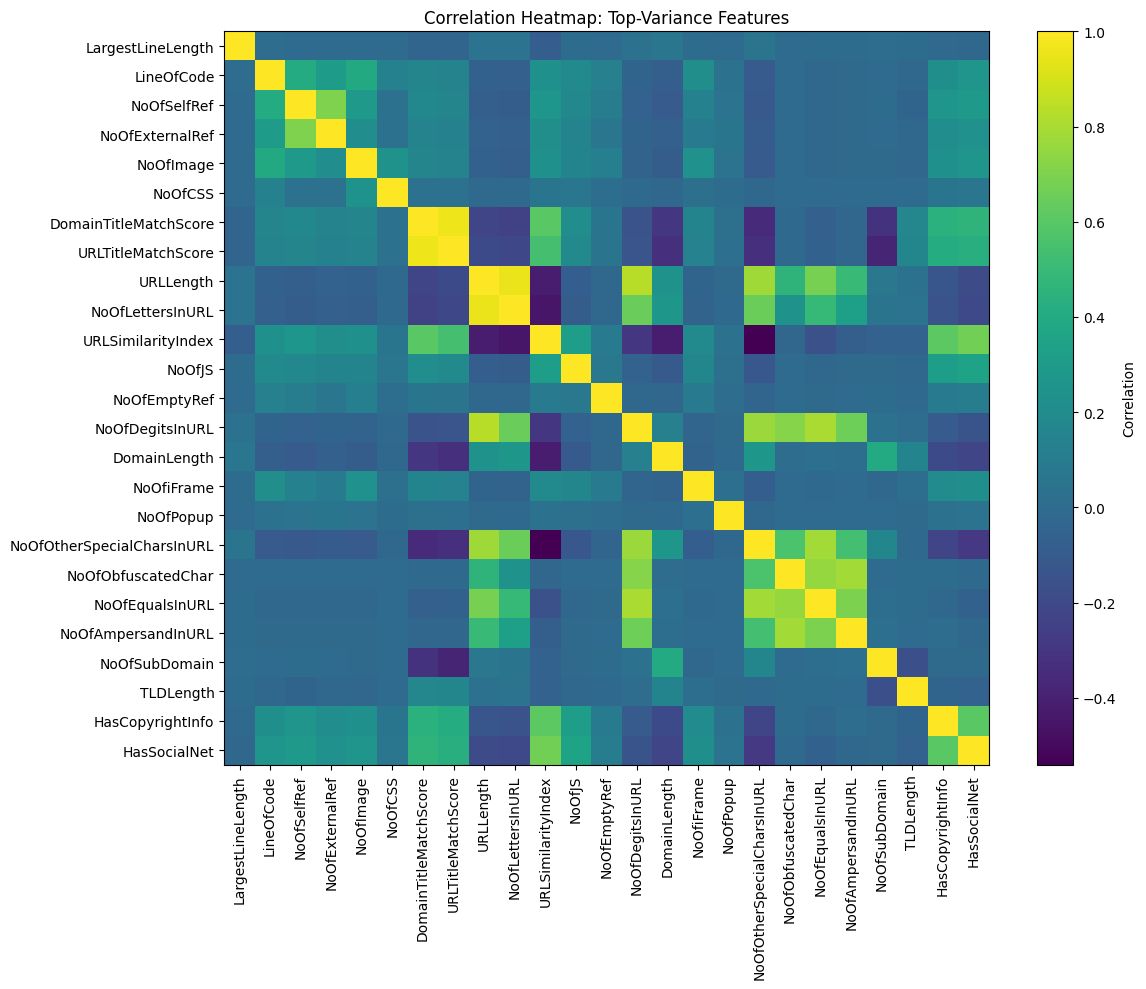

EDA outputs saved to: C:\Users\rahin\Documents\Masters Course\ML for DS\coursework\bhairebhai\phiusiil_5_member_ipynb_readme_only\member2_eda_feature_separability\outputs\eda_phiusiil


In [8]:
top_features = df[feature_cols].var().sort_values(ascending=False).head(25).index.tolist()
corr = df[top_features].corr()
corr.to_csv(OUTPUT_DIR / "correlation_top_variance_features.csv")

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Heatmap: Top-Variance Features")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_heatmap_top_variance_features.png", dpi=300)
plt.show()

print("EDA outputs saved to:", OUTPUT_DIR)